In [13]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [15]:
IMG_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.5
DENSE_UNITS = 512
EPOCHS = 50

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))


test_dir = os.path.join(BASE_DIR, "data", "preprocessed_split_2","test")
train_dir = os.path.join(BASE_DIR, "data", "preprocessed_split_2","train")
val_dir = os.path.join(BASE_DIR, "data", "preprocessed_split_2","val")
train2_dir = os.path.join(BASE_DIR, "data", "preprocessed_split_2","train2")


train_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

train2_generator = train_datagen.flow_from_directory(
    train2_dir, 
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generater = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 2325 images belonging to 2 classes.
Found 1821 images belonging to 2 classes.
Found 661 images belonging to 2 classes.
Found 333 images belonging to 2 classes.


In [16]:
base_model = DenseNet121(weights=None, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

In [17]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(DENSE_UNITS, activation='relu')(x)
x = Dropout(DROPOUT_RATE)(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)


In [18]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-7),
    ModelCheckpoint('best_densenetds2.keras', monitor='val_accuracy', save_best_only=True)
]

In [20]:
history1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7097 - loss: 0.5733 - val_accuracy: 0.5113 - val_loss: 0.6748 - learning_rate: 1.0000e-04
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7424 - loss: 0.5453 - val_accuracy: 0.5204 - val_loss: 0.6599 - learning_rate: 1.0000e-04
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7488 - loss: 0.5238 - val_accuracy: 0.5855 - val_loss: 0.6375 - learning_rate: 1.0000e-04
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7510 - loss: 0.5131 - val_accuracy: 0.6611 - val_loss: 0.6166 - learning_rate: 1.0000e-04
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7617 - loss: 0.5037 - val_accuracy: 0.6732 - val_loss: 0.5821 - learning_rate: 1.0000e-04
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7574 - loss: 0.5054 - val_accuracy: 0.6657 - val_loss: 0.5620 - learning_rate: 1.0000e-04
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7665 

In [21]:
import json

# Save history
with open("dense_H1.json", "w") as f:
    json.dump(history1.history, f)

In [22]:
base_model.trainable = True
model.compile(optimizer=Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
history2 = model.fit(
    train2_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 477s 7s/step - accuracy: 0.8083 - loss: 0.9350 - val_accuracy: 0.5113 - val_loss: 9.3251 - learning_rate: 1.0000e-05
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 374s 7s/step - accuracy: 0.8781 - loss: 0.4753 - val_accuracy: 0.5113 - val_loss: 10.6108 - learning_rate: 1.0000e-05
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 366s 6s/step - accuracy: 0.8814 - loss: 0.4525 - val_accuracy: 0.5113 - val_loss: 5.8670 - learning_rate: 1.0000e-05
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 368s 6s/step - accuracy: 0.8924 - loss: 0.4049 - val_accuracy: 0.5113 - val_loss: 10.7905 - learning_rate: 1.0000e-05
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 416s 7s/step - accuracy: 0.9231 - loss: 0.2844 - val_accuracy: 0.5098 - val_loss: 9.9954 - learning_rate: 1.0000e-05
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 424s 7s/step - accuracy: 0.9066 - loss: 0.3636 - val_accuracy: 0.5113 - val_loss: 10.8227 - learning_rate: 2.0000e-06
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 376s 7s/step - accuracy: 0.92

In [30]:
import json

# Save history
with open("dense_H2.json", "w") as f:
    json.dump(history2.history, f)

In [ ]:
# history3 = model.fit(
#     train_generator,
#     epochs=10,
#     validation_data=val_generator,
#     callbacks=callbacks
# )

In [ ]:
# import json

# # Save history
# with open("dense_H3.json", "w") as f:
#     json.dump(history3.history, f)

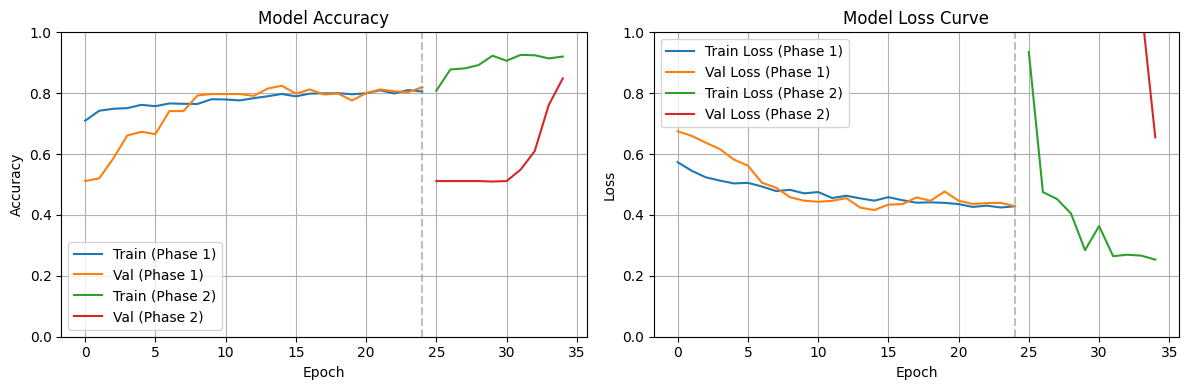

In [32]:
# Combined History (Phase 1 + 2)
full_epochs1 = len(history1.history['accuracy'])
full_epochs2 = len(history2.history['accuracy'])
total_epochs = full_epochs1 + full_epochs2

plt.figure(figsize=(12, 4))

# ---------------- Accuracy Plot ----------------
plt.subplot(1, 2, 1)

plt.plot(history1.history['accuracy'], label='Train (Phase 1)')
plt.plot(history1.history['val_accuracy'], label='Val (Phase 1)')

# Phase divider
plt.axvline(x=full_epochs1-1, linestyle='--', alpha=0.5, color='gray')

# Phase 2
plt.plot(np.arange(full_epochs1, total_epochs),
         history2.history['accuracy'], label='Train (Phase 2)')
plt.plot(np.arange(full_epochs1, total_epochs),
         history2.history['val_accuracy'], label='Val (Phase 2)')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.ylim(0, 1)   # Y-axis from 0 to 1
plt.legend()
plt.grid(True)

# ---------------- Loss Plot ----------------
plt.subplot(1, 2, 2)

plt.plot(history1.history['loss'], label='Train Loss (Phase 1)')
plt.plot(history1.history['val_loss'], label='Val Loss (Phase 1)')

# Phase divider
plt.axvline(x=full_epochs1-1, linestyle='--', alpha=0.5, color='gray')

# Phase 2
plt.plot(np.arange(full_epochs1, total_epochs),
         history2.history['loss'], label='Train Loss (Phase 2)')
plt.plot(np.arange(full_epochs1, total_epochs),
         history2.history['val_loss'], label='Val Loss (Phase 2)')

plt.title('Model Loss Curve')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.ylim(0, 1)   # Y-axis from 0 to 1
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [29]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
model_dir = os.path.join(BASE_DIR, "final-1")

os.makedirs(model_dir, exist_ok=True)

model.save(os.path.join(model_dir, "Best_DN_Ever.keras"))

In [ ]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

dn_dir = os.path.join(BASE_DIR, "experiments", "final-1", "Final_DenseNet_trained.keras")

model = tf.keras.models.load_model(dn_dir)

In [24]:
val_loss, val_acc = model.evaluate(val_generator)
print(f'Validation Accuracy: {val_acc:.4f} [web:1]')

21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8487 - loss: 0.6551
Validation Accuracy: 0.8487 [web:1]


11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       162
           1       0.79      0.95      0.86       171

    accuracy                           0.84       333
   macro avg       0.86      0.84      0.84       333
weighted avg       0.86      0.84      0.84       333



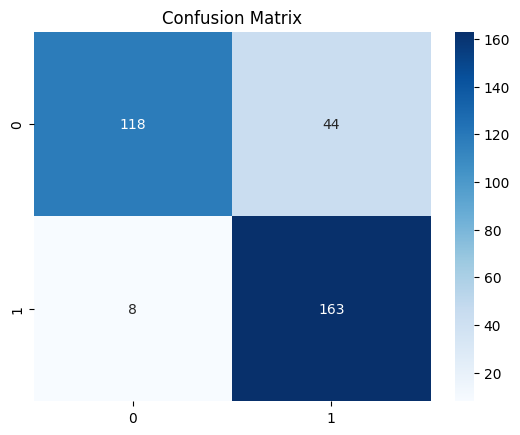

In [25]:
y_pred = (model.predict(test_generater) > 0.5).astype(int).flatten()
y_true = test_generater.classes[:len(y_pred)]
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 758ms/step


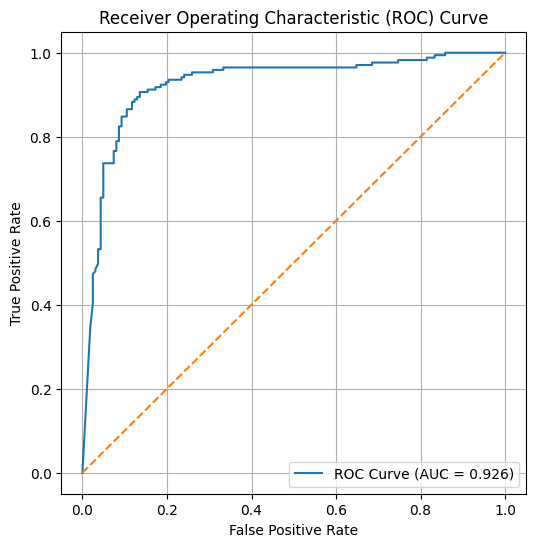

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_pred_prob = model.predict(test_generater).ravel()

# True labels
y_true = test_generater.classes[:len(y_pred_prob)]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


In [28]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..",".."))

test_tumor_dir = os.path.join(BASE_DIR, "data","test_data","Tumor")



IMG_SIZE = (224, 224)

def preprocess_image(img_path):
    
    # Load image in RGB (same as training generator)
    img = image.load_img(
        img_path,
        target_size=IMG_SIZE,
        color_mode="rgb"
    )
    
    # Convert to numpy array
    img_array = image.img_to_array(img)
    
    # Normalize (same as rescale=1./255)
    img_array = img_array / 255.0
    
    # Add batch dimension (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)
    
    return img_array


for img_name in os.listdir(test_tumor_dir):

    img_path = os.path.join(test_tumor_dir, img_name)

    # Skip non-image files
    if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    img_array = preprocess_image(img_path)

    prediction = model.predict(img_array)

    probability = prediction[0][0]

    if probability > 0.5:
        result = "Tumor Detected"
    else:
        result = "No Tumor"

    print(f"{img_name} -> {result} (Confidence: {probability:.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
tumor.jpeg -> Tumor Detected (Confidence: 0.9776)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
tumor1.jpeg -> Tumor Detected (Confidence: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
tumor2.jpeg -> Tumor Detected (Confidence: 0.8607)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
tumor3.jpeg -> No Tumor (Confidence: 0.0091)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
WhatsApp Image 2026-03-03 at 10.13.25 PM.jpeg -> No Tumor (Confidence: 0.2976)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
WhatsApp Image 2026-03-03 at 10.14.36 PM.jpeg -> No Tumor (Confidence: 0.2815)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
WhatsApp Image 2026-03-03 at 10.15.59 PM.jpeg -> No Tumor (Confidence: 0.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
WhatsApp Image 2026-03-03 at 10.16.50 PM.jpeg -> Tumor Detected (Confidence: 0.9154)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
WhatsApp Image 2026-03-03 at 10.18.01 PM.jpeg -> Tumor Detected (Confidence: 0.9108)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
WhatsApp Image 